# Reconstructing latent measures

This notebook reproduces the reconstruction experiment. Each latent
one-dimensional Gaussian measure is replaced by an empirical distribution
from a finite inner sample.

The experiment compares plug-in metric variance with the latent-measure
oracle. It also records the Wasserstein reconstruction scale for each inner
sample size.

In [1]:
from pathlib import Path
import sys

candidate = Path.cwd().resolve()
if (candidate / "src").is_dir():
    PUBLIC_ROOT = candidate
elif (candidate.parent / "src").is_dir():
    PUBLIC_ROOT = candidate.parent
else:
    raise RuntimeError("Start Jupyter in public or public/notebooks.")

sys.path.insert(0, str(PUBLIC_ROOT / "src"))
DATA_DIR = PUBLIC_ROOT / "data"
print(f"Public package: {PUBLIC_ROOT.name}")

Public package: public


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import ndtri

from bmu.simulation_core import (
    complete_component_estimates,
    metric_variance_of_rows,
)

plt.style.use("seaborn-v0_8-whitegrid")
PAPER_SCALE = False

## Archived paper-scale result

The stored output contains the full run used by the manuscript. Both axes are
logarithmic, which makes the nearly quadratic relation visible.

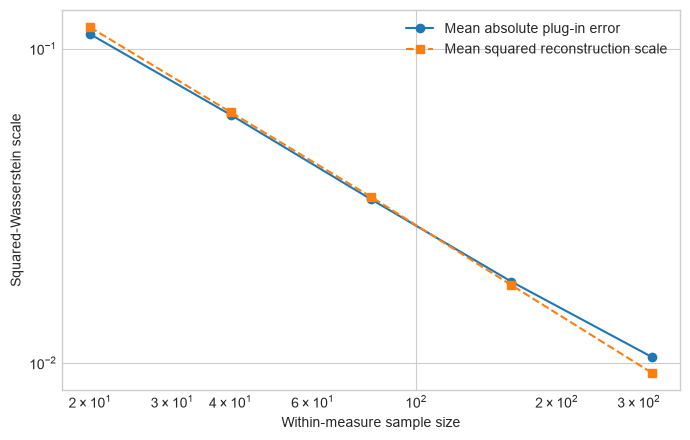

,inner_sample_size,mean_signed_error,mean_absolute_error,rmse,q90_absolute_error,mean_reconstruction_rms,mean_squared_reconstruction_scale,repetitions,loglog_slope_mae_vs_rms
0,20,0.11087,0.11115,0.11910,0.16445,0.34139,0.11684,700,1.88104
1,40,0.06134,0.06157,0.06777,0.10169,0.25031,0.06279,700,1.88104
2,80,0.03206,0.03317,0.03827,0.05931,0.18352,0.03376,700,1.88104
3,160,0.01635,0.01814,0.02184,0.03603,0.13286,0.01769,700,1.88104
4,320,0.00810,0.01045,0.01306,0.02166,0.09638,0.00930,700,1.88104


In [3]:
paper_results = pd.read_csv(DATA_DIR / "simulation_plugin.csv")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.loglog(
    paper_results["inner_sample_size"],
    paper_results["mean_absolute_error"],
    marker="o",
    label="Mean absolute plug-in error",
)
ax.loglog(
    paper_results["inner_sample_size"],
    paper_results["mean_squared_reconstruction_scale"],
    marker="s",
    linestyle="--",
    label="Mean squared reconstruction scale",
)
ax.set(
    xlabel="Within-measure sample size",
    ylabel="Squared-Wasserstein scale",
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

paper_results.round(5)

## Fresh reconstruction check

The quick run uses fewer outer measures and replications. Set `PAPER_SCALE` to
`True` to restore every manuscript setting.

In [4]:
def run_reconstruction(n, repetitions, inner_sizes, seed=20260715):
    rng = np.random.default_rng(seed)
    rows = []
    for inner_n in inner_sizes:
        absolute_errors = []
        reconstruction_rms = []
        u_mid = (np.arange(inner_n) + 0.5) / inner_n
        normal_mid = ndtri(u_mid)

        for _ in range(repetitions):
            location = rng.normal(0.0, 0.8, n)
            scale = np.exp(rng.normal(-0.05, 0.22, n))
            oracle = complete_component_estimates(
                np.column_stack([location, scale])
            )[0]
            sample = location[:, None] + scale[:, None] * rng.normal(
                size=(n, inner_n)
            )
            empirical = np.sort(sample, axis=1)
            plugin = metric_variance_of_rows(empirical)
            truth = location[:, None] + scale[:, None] * normal_mid[None, :]
            delta2 = np.mean((empirical - truth) ** 2, axis=1)
            absolute_errors.append(abs(plugin - oracle))
            reconstruction_rms.append(np.sqrt(np.mean(delta2)))

        absolute_errors = np.asarray(absolute_errors)
        reconstruction_rms = np.asarray(reconstruction_rms)
        rows.append(
            {
                "inner_sample_size": inner_n,
                "mean_absolute_error": absolute_errors.mean(),
                "mean_reconstruction_rms": reconstruction_rms.mean(),
                "mean_squared_reconstruction_scale": np.mean(
                    reconstruction_rms**2
                ),
                "repetitions": repetitions,
            }
        )
    result = pd.DataFrame(rows)
    slope = np.polyfit(
        np.log(result["mean_reconstruction_rms"]),
        np.log(result["mean_absolute_error"]),
        1,
    )[0]
    result["loglog_slope_mae_vs_rms"] = slope
    return result


if PAPER_SCALE:
    fresh_results = run_reconstruction(
        n=80,
        repetitions=700,
        inner_sizes=[20, 40, 80, 160, 320],
    )
else:
    fresh_results = run_reconstruction(
        n=50,
        repetitions=80,
        inner_sizes=[20, 40, 80, 160],
    )

fresh_results.round(5)

,inner_sample_size,mean_absolute_error,mean_reconstruction_rms,mean_squared_reconstruction_scale,repetitions,loglog_slope_mae_vs_rms
0,20,0.11103,0.34176,0.11725,80,1.89598
1,40,0.07020,0.25281,0.06410,80,1.89598
2,80,0.04063,0.18523,0.03447,80,1.89598
3,160,0.01844,0.13330,0.01783,80,1.89598


The plug-in error follows the squared reconstruction scale. This pattern
supports the sharper second-order argument under conditional centering, while
the general pathwise bound remains more conservative.